In [ ]:
import numpy as np
import pandas as pd

# 加载 .npz 文件
data = np.load('../singleset/p3ht_singleset128.npz',allow_pickle=True)

# 'mol list', 'tempearture', 'total time', 'other info', 'r square array', 
# 'electron occupations array', 'phonon occupations array', 'k occupations array', 
# 'eph entropy', 'bond entropy', 'coherent length array', 'time series'
df = data['e_occupations']

df = pd.DataFrame(df)
print(df)
df.to_excel('p3ht_128_singleset.xlsx', index=False)

           0             1             2             3             4   \
0    1.000000  2.206063e-20  1.938605e-21  1.150238e-21  1.130178e-21   
1    0.889750  2.185350e-02  1.285741e-04  3.499993e-07  4.357479e-09   
2    0.616630  7.415090e-02  1.850378e-03  1.962527e-05  1.214332e-07   
3    0.316353  1.266575e-01  7.855902e-03  1.966522e-04  2.696555e-06   
4    0.118784  1.530654e-01  1.943043e-02  9.234732e-04  2.327864e-05   
..        ...           ...           ...           ...           ...   
197  0.074866  7.043419e-03  6.217457e-03  1.007945e-02  1.278557e-02   
198  0.072551  7.408705e-03  6.252635e-03  9.942603e-03  1.326328e-02   
199  0.070921  7.970757e-03  6.383061e-03  9.849277e-03  1.385207e-02   
200  0.069742  8.525591e-03  6.585245e-03  9.842548e-03  1.451021e-02   
201  0.068830  8.873207e-03  6.840695e-03  9.951082e-03  1.519125e-02   

               5             6             7             8             9   \
0    1.132030e-21  1.132816e-21  1.132991e-21 

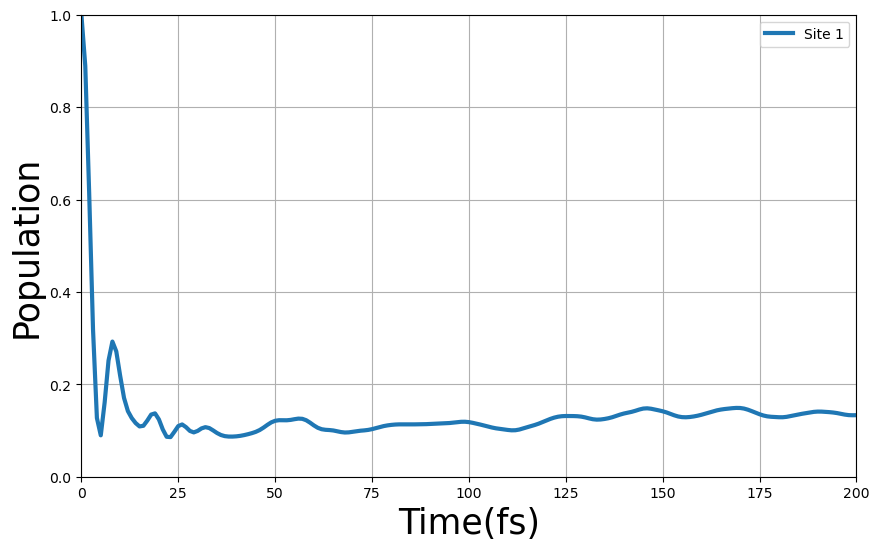

In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

excel_path = Path('p3ht_16_multiset.xlsx')

if not excel_path.exists():
    print(f'Skip: {excel_path} does not exist')
else:
    # 读取Excel文件
    df = pd.read_excel(excel_path)
    # df = pd.read_excel('../../fmo_benchmark.xlsx')

    # 提取数据
    x = np.arange(0,df.shape[0],1)
    x = x * 1 

    y_columns = df.iloc[:, 0:1]  # 第1-7列作为y坐标

    # 创建图表
    plt.figure(figsize=(10, 6))

    # 绘制七条线
    for i in range(0,y_columns.shape[1]):
        plt.plot(x, y_columns.iloc[:, i],label=f'Site {i+1}',linewidth=3)

    # 添加图表元素
    plt.xlabel('Time(fs)',size = 25)
    plt.ylabel('Population',size = 25)
    plt.xlim((0, 200))
    plt.ylim((0, 1))
    plt.title('')
    plt.legend()
    plt.grid(True)

    # 显示图表
    plt.show()

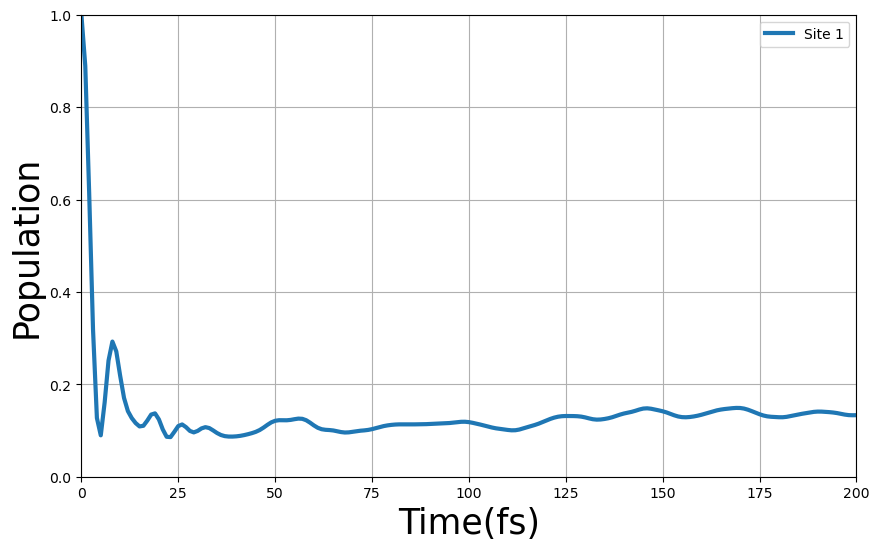

In [10]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

excel_path = Path('p3ht_16_multiset.xlsx')

if not excel_path.exists():
    print(f'Skip: {excel_path} does not exist')
else:
    # 读取Excel文件
    df = pd.read_excel(excel_path)
    # df = pd.read_excel('../../fmo_benchmark.xlsx')

    # 提取数据
    x = np.arange(0,df.shape[0],1)
    x = x * 1 

    y_columns = df.iloc[:, 0:1]  # 第1-7列作为y坐标

    # 创建图表
    plt.figure(figsize=(10, 6))

    # 绘制七条线
    for i in range(0,y_columns.shape[1]):
        plt.plot(x, y_columns.iloc[:, i],label=f'Site {i+1}',linewidth=3)

    # 添加图表元素
    plt.xlabel('Time(fs)',size = 25)
    plt.ylabel('Population',size = 25)
    plt.xlim((0, 200))
    plt.ylim((0, 1))
    plt.title('')
    plt.legend()
    plt.grid(True)

    # 显示图表
    plt.show()

In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

datasets = [
    # ('16', 'p3ht_16_multiset.xlsx', 'p3ht_16_singleset.xlsx'),
    ('32', 'p3ht_32_multiset.xlsx', 'p3ht_32_singleset.xlsx'),
    ('64', 'p3ht_64_multiset.xlsx', 'p3ht_64_singleset.xlsx'),
    ('128', 'p3ht_128_multiset.xlsx', 'p3ht_128_singleset.xlsx'),
]

colors = {'16': 'tab:blue', '32': 'tab:orange', '64': 'tab:green', '128': 'tab:red'}
zoom_start, zoom_end = 150, 200
zoom_values = []
plotted = False

fig, (ax, ax_zoom) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    constrained_layout=True,
    gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.12},
)

for size, multiset_file, singleset_file in datasets:
    multiset_path = Path(multiset_file)
    singleset_path = Path(singleset_file)
    color = colors[size]

    if singleset_path.exists():
        df_single = pd.read_excel(singleset_path)
        x_single = np.arange(df_single.shape[0])
        y_single = df_single.iloc[:, 0:1].iloc[:, 0]
        zoom_values.extend(y_single[(x_single >= zoom_start) & (x_single <= zoom_end)].tolist())

        ax.plot(x_single, y_single, color=color, linewidth=2.5, label=f'{size} singleset')
        ax_zoom.plot(x_single, y_single, color=color, linewidth=2.5)
        plotted = True
    else:
        print(f'Skip {size} singleset: missing {singleset_path}')

    if multiset_path.exists():
        df_multi = pd.read_excel(multiset_path)
        x_multi = np.arange(df_multi.shape[0])
        y_multi = df_multi.iloc[:, 0:1].iloc[:, 0]
        zoom_values.extend(y_multi[(x_multi >= zoom_start) & (x_multi <= zoom_end)].tolist())

        ax.plot(
            x_multi,
            y_multi,
            color=color,
            linestyle='None',
            marker='^',
            markersize=5,
            markevery=10,
            label=f'{size} multiset',
        )
        ax_zoom.plot(
            x_multi,
            y_multi,
            color=color,
            linestyle='None',
            marker='^',
            markersize=5,
            markevery=2,
        )
        plotted = True
    else:
        print(f'Skip {size} multiset: missing {multiset_path}')

if not plotted:
    plt.close(fig)
    print('Skip plot: no dataset files found')
else:
    ax.set_xlabel('Time(fs)', size=18)
    ax.set_ylabel('Population', size=18)
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()

    ax_zoom.set_xlim(zoom_start, zoom_end)
    if zoom_values:
        zoom_min = min(zoom_values)
        zoom_max = max(zoom_values)
        zoom_margin = max((zoom_max - zoom_min) * 0.1, 1e-4)
        ax_zoom.set_ylim(zoom_min - zoom_margin, zoom_max + zoom_margin)
    ax_zoom.set_ylim(0.06, 0.14)
    ax_zoom.set_ylabel('Population', size=18)
    ax_zoom.set_title('150-200 fs', size=14)
    ax_zoom.grid(True, alpha=0.3)

    plt.show()


In [ ]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

benchmark_path = Path("p3ht_128_singleset.xlsx")
dt_fs = 1.0

data_files = [
    ("16 singleset", Path("p3ht_16_singleset.xlsx"), "tab:blue", "--", 2.5),
    ("16 multiset", Path("p3ht_16_multiset.xlsx"), "tab:blue", "-", 2.5),
    ("32 singleset", Path("p3ht_32_singleset.xlsx"), "tab:orange", "--", 2.5),
    ("32 multiset", Path("p3ht_32_multiset.xlsx"), "tab:orange", "-", 2.5),
    ("64 singleset", Path("p3ht_64_singleset.xlsx"), "tab:green", "--", 2.5),
    ("64 multiset", Path("p3ht_64_multiset.xlsx"), "tab:green", "-", 2.5),
    ("128 singleset benchmark", Path("p3ht_128_singleset.xlsx"), "tab:red", "--", 2.5),
    ("128 multiset", Path("p3ht_128_multiset.xlsx"), "tab:red", "-", 2.5),
]


def load_population_excel(path):
    return pd.read_excel(path, header=None).to_numpy(dtype=float)


def average_cumulative_error(y_pred, x_pred, y_bm, x_bm):
    n_col = y_bm.shape[1]
    if y_pred.shape[1] < n_col:
        raise ValueError(f"expected at least {n_col} columns, got {y_pred.shape[1]}")

    y_pred = y_pred[:, :n_col]
    y_bm_interp = np.column_stack([
        np.interp(x_pred, x_bm, y_bm[:, i]) for i in range(n_col)
    ])

    abs_err = np.abs(y_pred - y_bm_interp)
    cum_err = np.zeros(len(x_pred), dtype=float)
    if len(x_pred) > 1:
        dt_seg = np.diff(x_pred)
        seg_integral = 0.5 * (abs_err[1:] + abs_err[:-1]) * dt_seg[:, None]
        cumulative_integral = np.cumsum(seg_integral, axis=0)
        cum_err[1:] = np.sum(cumulative_integral, axis=1) / (n_col * x_pred[1:])
    return cum_err


if not benchmark_path.exists():
    print(f"Skip ACE plot: benchmark file missing {benchmark_path}")
else:
    y_bm = load_population_excel(benchmark_path)
    x_bm = np.arange(len(y_bm)) * dt_fs
    n_col = y_bm.shape[1]
    print(f"Benchmark: {benchmark_path}, rows={len(y_bm)}, columns={n_col}, dt={dt_fs} fs")

    fig, ax = plt.subplots(figsize=(10, 6))
    plotted = False
    for label, path, color, linestyle, linewidth in data_files:
        if not path.exists():
            print(f"Skip {label}: missing {path}")
            continue

        y_pred = load_population_excel(path)
        if y_pred.shape[1] < n_col:
            print(f"Skip {label}: expected at least {n_col} columns, got {y_pred.shape[1]}")
            continue

        x_pred = np.arange(len(y_pred)) * dt_fs
        cum_err = average_cumulative_error(y_pred, x_pred, y_bm, x_bm)
        ax.plot(x_pred, cum_err, label=label, color=color, linestyle=linestyle, linewidth=linewidth)
        plotted = True
        print(f"{label}: max ACE={cum_err.max():.4e}, mean ACE={cum_err.mean():.4e}")

    if not plotted:
        plt.close(fig)
        print("Skip ACE plot: no comparable data files found")
    else:
        ax.set_xlabel("Time (fs)", fontsize=16)
        ax.set_ylabel("Average Cumulative Error", fontsize=16)
        ax.set_title("Average Cumulative Error vs. 128 singleset Benchmark\nP3HT:PCBM", fontsize=16)
        ax.set_xlim(left=0, right=200)
        ax.set_ylim(bottom=0)
        ax.tick_params(labelsize=13)
        ax.legend(fontsize=12, framealpha=0.85, edgecolor="gray")
        ax.grid(True, alpha=0.35)
        plt.tight_layout()
        plt.savefig("P3HT_avg_cumulative_error_vs_128_singleset.png", dpi=150)
        plt.show()
